In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df = pd.read_csv('crop_yield_cleaned_sample.csv')

In [ ]:
df.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,North,Sandy,Cotton,111.876620,17.051596,1,0,Rainy,68,2.852138
1,North,Chalky,Rice,951.642084,29.666202,0,0,Rainy,134,5.093429
2,East,Chalky,Cotton,530.366192,33.075723,0,0,Cloudy,74,3.174245
3,South,Chalky,Cotton,918.940015,15.987808,1,1,Cloudy,104,8.241967
4,West,Peaty,Barley,124.806838,17.293317,0,1,Rainy,103,2.051171


In [ ]:
df.isnull().sum()

Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64

In [ ]:
print(df['Region'].nunique())
print(df['Soil_Type'].nunique())
print(df['Crop'].nunique())
print(df['Weather_Condition'].nunique())

4
6
6
3


In [ ]:
df = pd.get_dummies(
    df,
    columns=['Region', 'Soil_Type', 'Crop', 'Weather_Condition'],
    drop_first=True
)


df = df.astype(int, errors='ignore')

In [ ]:
df.shape

(10000, 21)

In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop('Yield_tons_per_hectare', axis=1)
y = df['Yield_tons_per_hectare']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)


In [ ]:
print(X_train.shape)
print(X_test.shape)

(8000, 20)
(2000, 20)


In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

In [ ]:
print(y_pred[:10])

[4.29635385 2.36096077 1.11891943 1.48105077 7.48938631 5.69989434
 4.76050172 6.97018956 4.89299057 1.94559857]


In [ ]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("R² :", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R² : 0.8815146960994384
MAE: 0.46611061279995986
RMSE: 0.5819903124504484


In [ ]:
print("Train R²:", lr.score(X_train,y_train))
print("Test R²:", lr.score(X_test,y_test))

Train R²: 0.8868739004387787
Test R²: 0.8815146960994384


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    Ridge(),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

best_ridge = ridge_grid.best_estimator_
print("Best Alpha:", ridge_grid.best_params_)
print("Best CV Score:", ridge_grid.best_score_)

y_pred_ridge = best_ridge.predict(X_test) 

r2 = r2_score(y_test, y_pred_ridge)
mae = mean_absolute_error(y_test, y_pred_ridge)
rmse = mean_squared_error(y_test, y_pred_ridge) ** 0.5

print("R² :", r2)
print("MAE:", mae)
print("RMSE:", rmse)
print("Train R²:", best_ridge.score(X_train, y_train))
print("Test R² :", best_ridge.score(X_test, y_test))





best_ridge = ridge_grid.best_estimator_

Best Alpha: {'alpha': 1}
Best CV Score: 0.8861744446146679
R² : 0.8815144422605096
MAE: 0.46609737540729235
RMSE: 0.581990935868347
Train R²: 0.8868738225020332
Test R² : 0.8815144422605096


In [ ]:
print("Train R²:", best_ridge.score(X_train, y_train))
print("Test R² :", best_ridge.score(X_test, y_test))

Train R²: 0.8868738225020332
Test R² : 0.8815144422605096


In [ ]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Ridge_Coefficient": best_ridge.coef_ 
})


coef_df.sort_values(
    by="Ridge_Coefficient",
    key=abs,
    ascending=False
).head(10)

,Feature,Ridge_Coefficient
2,Fertilizer_Used,1.489067
3,Irrigation_Used,1.202748
13,Crop_Cotton,-0.032946
10,Soil_Type_Peaty,-0.032913
6,Region_South,-0.032270
16,Crop_Soybean,-0.026658
9,Soil_Type_Loam,-0.022680
1,Temperature_Celsius,0.019489
7,Region_West,-0.019321
11,Soil_Type_Sandy,-0.017737


In [ ]:
from sklearn.linear_model import Lasso


param_grid = {
    'alpha': [0.0001, 0.0005, 0.001, 0.005, 0.01]
}

lasso_grid = GridSearchCV(
    Lasso(max_iter=10000),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

print("Best Alpha:", lasso_grid.best_params_)
print("Best CV Score:", lasso_grid.best_score_)

best_lasso = lasso_grid.best_estimator_
y_pred_lasso = best_lasso.predict(X_test)

Best Alpha: {'alpha': 0.005}
Best CV Score: 0.8863264941222176


In [ ]:
print("R² :", r2_score(y_test, y_pred_lasso))
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("RMSE:", mean_squared_error(y_test, y_pred_lasso) ** 0.5)

R² : 0.8815967010101257
MAE: 0.46534784183000116
RMSE: 0.581788876817475


In [ ]:
print("Train R²:", best_lasso.score(X_train, y_train))
print("Test R² :", best_lasso.score(X_test, y_test))

Train R²: 0.8866139987085929
Test R² : 0.8815967010101257


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best Params:", dt_grid.best_params_)
print("Best CV Score:", dt_grid.best_score_)

best_dt = dt_grid.best_estimator_
y_pred_dt = best_dt.predict(X_test)

Best Params: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Score: 0.8693030341770317


In [ ]:
print("Train R²:", best_dt.score(X_train, y_train))
print("Test R² :", best_dt.score(X_test, y_test))

print("MAE :", mean_absolute_error(y_test, y_pred_dt))
print("RMSE:", mean_squared_error(y_test, y_pred_dt)**0.5)

Train R²: 0.8758917431502107
Test R² : 0.8607035549718727
MAE : 0.5098549636492419
RMSE: 0.6310351175753582


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_rf = grid.best_estimator_
y_pred = best_rf.predict(X_test)


Best Parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 300}
Best CV Score: 0.8786169836338296


In [ ]:
print("Train R²:", best_rf.score(X_train, y_train))
print("Test R² :", best_rf.score(X_test, y_test))

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred)**0.5)

Train R²: 0.9313427964407048
Test R² : 0.8743653276106708
MAE : 0.47693567968115563
RMSE: 0.5992917071042978



Top Features:
                    Feature  Importance
0               Rainfall_mm    0.621647
2           Fertilizer_Used    0.203734
3           Irrigation_Used    0.130500
1       Temperature_Celsius    0.016152
4           Days_to_Harvest    0.012232
10          Soil_Type_Peaty    0.001298
17               Crop_Wheat    0.001202
13              Crop_Cotton    0.001178
6              Region_South    0.001147
19  Weather_Condition_Sunny    0.001063


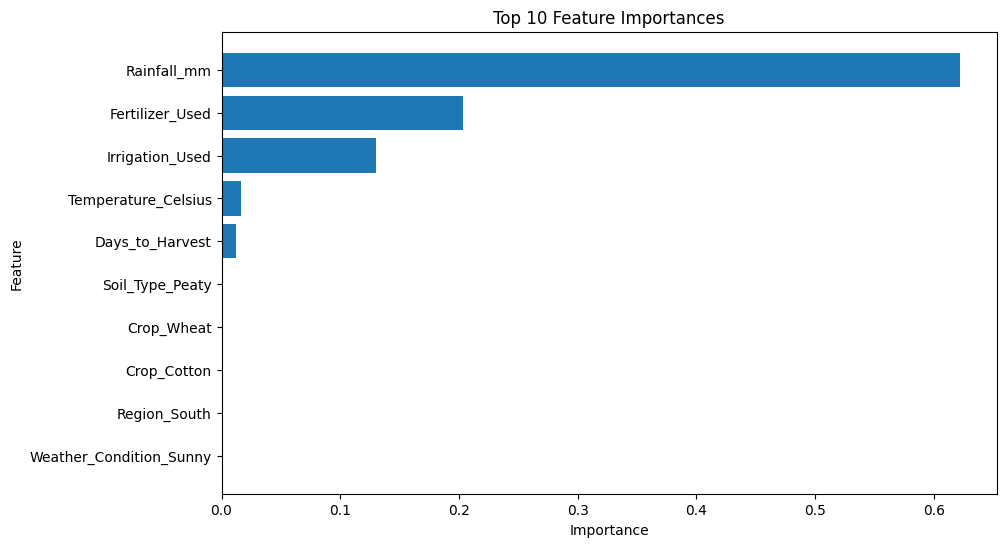

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

print("\nTop Features:")
print(importance.head(10))

# Feature Importance Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(
    importance['Feature'][:10],
    importance['Importance'][:10]
)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances')
plt.gca().invert_yaxis()
plt.show()

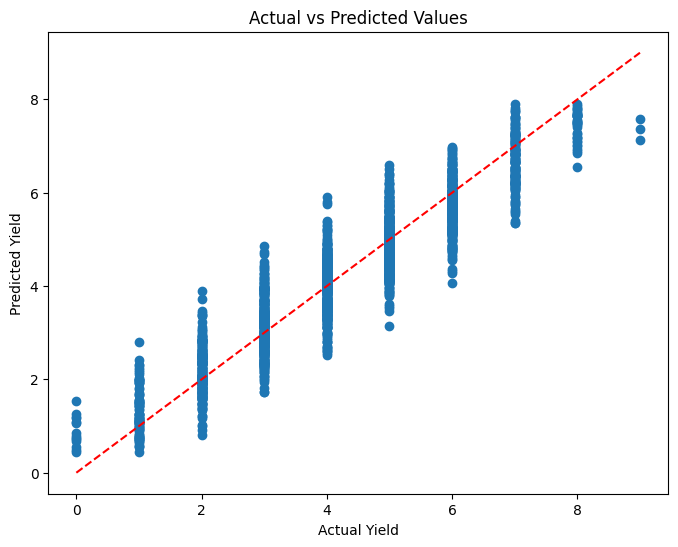

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Values")
plt.show()

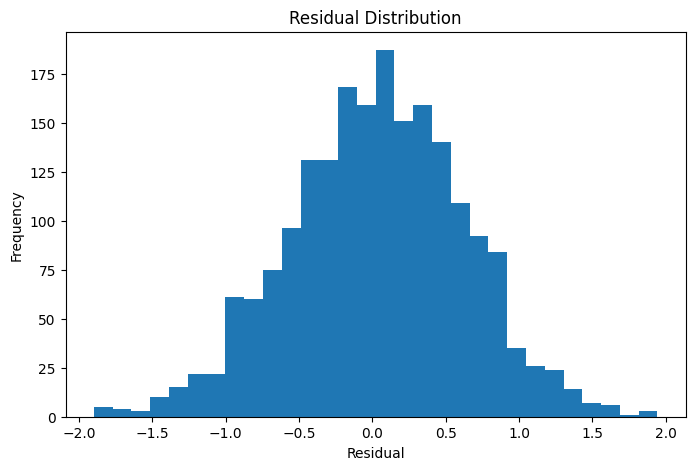

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge",
        "Lasso",
        "Decision Tree",
        "Random Forest"
    ],
    "Train R²": [
        lr.score(X_train,y_train),
        best_ridge.score(X_train,y_train),
        best_lasso.score(X_train,y_train),
        best_dt.score(X_train,y_train),
        best_rf.score(X_train,y_train)
    ],
    "Test R²": [
        lr.score(X_test,y_test),
        best_ridge.score(X_test,y_test),
        best_lasso.score(X_test,y_test),
        best_dt.score(X_test,y_test),
        best_rf.score(X_test,y_test)
    ]
})

comparison

,Model,Train R²,Test R²
0,Linear Regression,0.886874,0.881515
1,Ridge,0.886874,0.881514
2,Lasso,0.886614,0.881597
3,Decision Tree,0.875892,0.860704
4,Random Forest,0.931343,0.874365


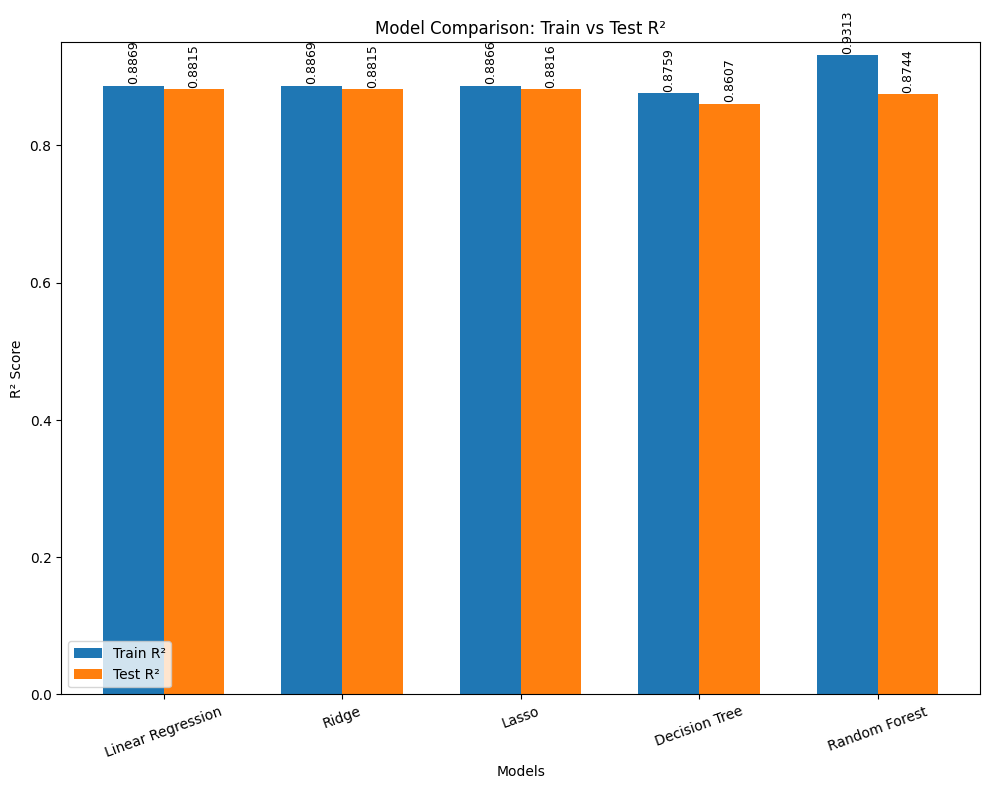

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(comparison["Model"]))
width = 0.34

fig, ax = plt.subplots(figsize=(10,8))

bars1 = ax.bar(
    x - width/2,
    comparison["Train R²"],
    width,
    label="Train R²"
)

bars2 = ax.bar(
    x + width/2,
    comparison["Test R²"],
    width,
    label="Test R²"
)

# Value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.003,
        f'{height:.4f}',
        ha='center',
        va='bottom',
        fontsize=9,
        rotation=90
    )

for bar in bars2:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.003,
        f'{height:.4f}',
        ha='center',
        va='bottom',
        fontsize=9,
        rotation=90
    )

ax.set_xticks(x)
ax.set_xticklabels(comparison["Model"], rotation=20)

ax.set_ylabel("R² Score")
ax.set_xlabel("Models")
ax.set_title("Model Comparison: Train vs Test R²")
ax.legend()

# Zoom in so differences become visible
ax.set_ylim(0, 0.95)

plt.tight_layout()
plt.show()

## Pipeline


In [ ]:

import joblib


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline



df_pipeline = pd.read_csv(
    'crop_yield_cleaned_sample.csv'
)

X_pipe = df_pipeline.drop(
    'Yield_tons_per_hectare',
    axis=1
)

y_pipe = df_pipeline[
    'Yield_tons_per_hectare'
]

X_train_pipe, X_test_pipe, y_train_pipe, y_test_pipe = train_test_split(
    X_pipe,
    y_pipe,
    test_size=0.20,
    random_state=42
)

categorical_features = [
    'Region',
    'Soil_Type',
    'Crop',
    'Weather_Condition'
]

numerical_features = [
    'Rainfall_mm',
    'Temperature_Celsius',
    'Fertilizer_Used',
    'Irrigation_Used',
    'Days_to_Harvest'
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        ),
        (
            'numerical',
            'passthrough',
            numerical_features
        )
    ]
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

pipeline.fit(
    X_train_pipe,
    y_train_pipe
)

y_pred_pipeline = pipeline.predict(
    X_test_pipe
)

r2 = r2_score(
    y_test_pipe,
    y_pred_pipeline
)

mae = mean_absolute_error(
    y_test_pipe,
    y_pred_pipeline
)

rmse = mean_squared_error(
    y_test_pipe,
    y_pred_pipeline
) ** 0.5

print("Pipeline Results")
print("-" * 30)
print("R²   :", round(r2, 4))
print("MAE  :", round(mae, 4))
print("RMSE :", round(rmse, 4))

joblib.dump(
    pipeline,
    'crop_yield_pipeline.pkl'
)

print("\nPipeline Saved Successfully")

new_data = pd.DataFrame({
    'Region': ['North'],
    'Soil_Type': ['Loam'],
    'Crop': ['Wheat'],
    'Rainfall_mm': [120],
    'Temperature_Celsius': [28],
    'Fertilizer_Used': [1],
    'Irrigation_Used': [1],
    'Weather_Condition': ['Sunny'],
    'Days_to_Harvest': [110]
})

prediction = pipeline.predict(
    new_data
)

print(
    "\nPredicted Yield:",
    round(prediction[0], 2),
    "tons/hectare"
)

Pipeline Results
------------------------------
R²   : 0.9106
MAE  : 0.3935
RMSE : 0.4966

Pipeline Saved Successfully

Predicted Yield: 3.91 tons/hectare
